In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
!pip install torchvision
!pip install pandas
!pip install pynvml

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import time
import pandas as pd
from pynvml import *

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

100%|██████████| 170M/170M [00:08<00:00, 19.4MB/s]


In [5]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*6*6, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64*6*6)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()

# DataParallel wrapper
model = nn.DataParallel(model)

model = model.to(device)

print("Using device:", device)

Using device: cuda


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
nvmlInit()

handle = nvmlDeviceGetHandleByIndex(0)

gpu_logs = []

In [9]:
epochs = 1

for epoch in range(epochs):

    print("Epoch:", epoch+1)

    for batch_idx, (images, labels) in enumerate(train_loader):

        start_time = time.time()

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        batch_time = time.time() - start_time

        # GPU metrics
        mem_info = nvmlDeviceGetMemoryInfo(handle)

        gpu_logs.append({
            "batch": batch_idx,
            "loss": loss.item(),
            "batch_time": batch_time,
            "gpu_memory_used_MB": mem_info.used/1024**2
        })

        if batch_idx % 100 == 0:

            print(
                f"Batch {batch_idx} | Loss {loss.item():.4f} | Time {batch_time:.3f}s"
            )

Epoch: 1
Batch 0 | Loss 2.2987 | Time 1.216s
Batch 100 | Loss 1.8658 | Time 0.031s
Batch 200 | Loss 1.5011 | Time 0.005s
Batch 300 | Loss 1.3901 | Time 0.006s


In [10]:
df = pd.DataFrame(gpu_logs)

df.to_csv("gpu_training_metrics.csv", index=False)

print("Metrics saved to CSV")

Metrics saved to CSV


In [11]:
df.head()

,batch,loss,batch_time,gpu_memory_used_MB
0,0,2.298695,1.216331,704.1875
1,1,2.294958,0.010087,704.1875
2,2,2.334936,0.011355,704.1875
3,3,2.302930,0.012251,704.1875
4,4,2.304168,0.012939,704.1875


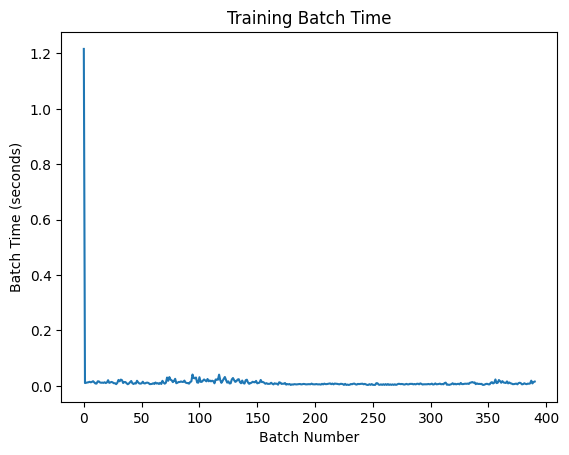

In [12]:
import matplotlib.pyplot as plt

plt.plot(df['batch_time'])
plt.xlabel("Batch Number")
plt.ylabel("Batch Time (seconds)")
plt.title("Training Batch Time")
plt.show()

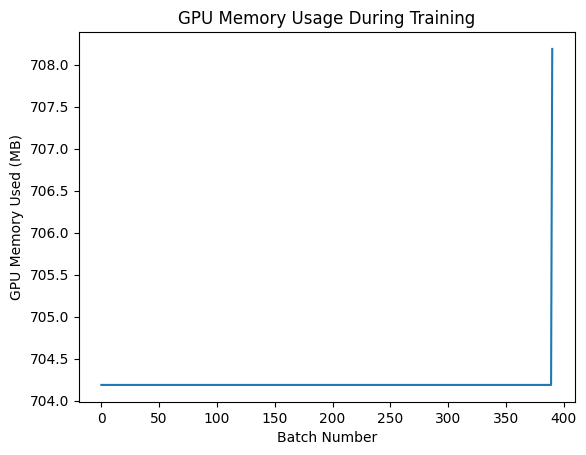

In [13]:
plt.plot(df['gpu_memory_used_MB'])
plt.xlabel("Batch Number")
plt.ylabel("GPU Memory Used (MB)")
plt.title("GPU Memory Usage During Training")
plt.show()